In [105]:
#importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
from sklearn import metrics 

In [106]:
# Cargar los DataFrames de entrenamiento y prueba
column_names = ["ValorFD1", "ValorFD2", "ValorFD3", "ValorFD4", "ValorFD5", "ax", "ay", "az", "gx", "gy", "gz", "target"]
data = pd.read_csv("datasets/valoresSensor.csv", names=column_names)

In [107]:
data.head()

,ValorFD1,ValorFD2,ValorFD3,ValorFD4,ValorFD5,ax,ay,az,gx,gy,gz,target
0,249.0,237.0,263.0,-14.0,11.0,6404,-9730,-258,-7938,-19200,-11520,NaN
1,257.0,245.0,271.0,-13.0,11.0,6472,-5108,-14392,-303,171,229,NaN
2,252.0,243.0,274.0,-13.0,9.0,6316,-5108,-14420,-291,143,207,NaN
3,255.0,247.0,271.0,-13.0,10.0,6392,-5044,-14244,-262,177,138,NaN
4,239.0,274.0,247.0,-14.0,9.0,6273,-1,-1,-288,131,208,NaN


In [108]:
# Muestra las dimenciones del dataset
data.shape

(1000, 12)

In [109]:
# Muestra informacion sobre las columnas y los tipos de datos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   ValorFD1  1000 non-null   float64
 1   ValorFD2  1000 non-null   float64
 2   ValorFD3  1000 non-null   float64
 3   ValorFD4  1000 non-null   float64
 4   ValorFD5  1000 non-null   float64
 5   ax        1000 non-null   int64  
 6   ay        1000 non-null   int64  
 7   az        1000 non-null   int64  
 8   gx        1000 non-null   int64  
 9   gy        1000 non-null   int64  
 10  gz        1000 non-null   int64  
 11  target    101 non-null    object 
dtypes: float64(5), int64(6), object(1)
memory usage: 93.9+ KB


In [110]:
# Muestra estadisticas descriptivas de las columnas numéricas
data.describe()

,ValorFD1,ValorFD2,ValorFD3,ValorFD4,ValorFD5,ax,ay,az,gx,gy,gz
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,234.622000,259.702000,275.48700,10.215000,-10.284000,14865.526000,-5535.824000,-1768.906000,-731.101000,-386.457000,318.023000
std,11.039973,13.436582,15.98347,8.347002,8.850858,2229.729202,2220.823457,4440.282904,1982.061854,1230.771436,1475.735017
min,184.000000,211.000000,196.00000,-14.000000,-20.000000,-2558.000000,-12836.000000,-28674.000000,-28418.000000,-19200.000000,-30719.000000
25%,230.000000,251.000000,269.00000,11.000000,-14.000000,14468.000000,-7016.000000,-4662.000000,-1160.000000,-592.500000,1.000000
50%,235.000000,263.000000,278.00000,13.000000,-13.000000,15484.000000,-5594.000000,-2072.000000,-736.500000,-194.000000,365.500000
75%,239.000000,267.000000,283.00000,14.000000,-12.000000,16033.000000,-4251.000000,1295.000000,-382.750000,132.250000,722.500000
max,283.000000,322.000000,390.00000,19.000000,18.000000,17448.000000,868.000000,10836.000000,20734.000000,2089.000000,5962.000000


In [141]:
print(data['target'].isnull().sum())

900


In [111]:
# Convertir las columnas a tipo numérico
for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors='coerce')  # 'coerce' convierte valores no numéricos a NaN

In [112]:
ms_copy=data.copy()

In [113]:
# Eliminar la última columna "target"
ms_copy = ms_copy.drop("target", axis=1)

In [114]:
# Convertir las columnas a tipo numérico
for col in ms_copy.columns:
    ms_copy[col] = pd.to_numeric(ms_copy[col], errors='coerce')  # 'coerce' convierte valores no numéricos a NaN

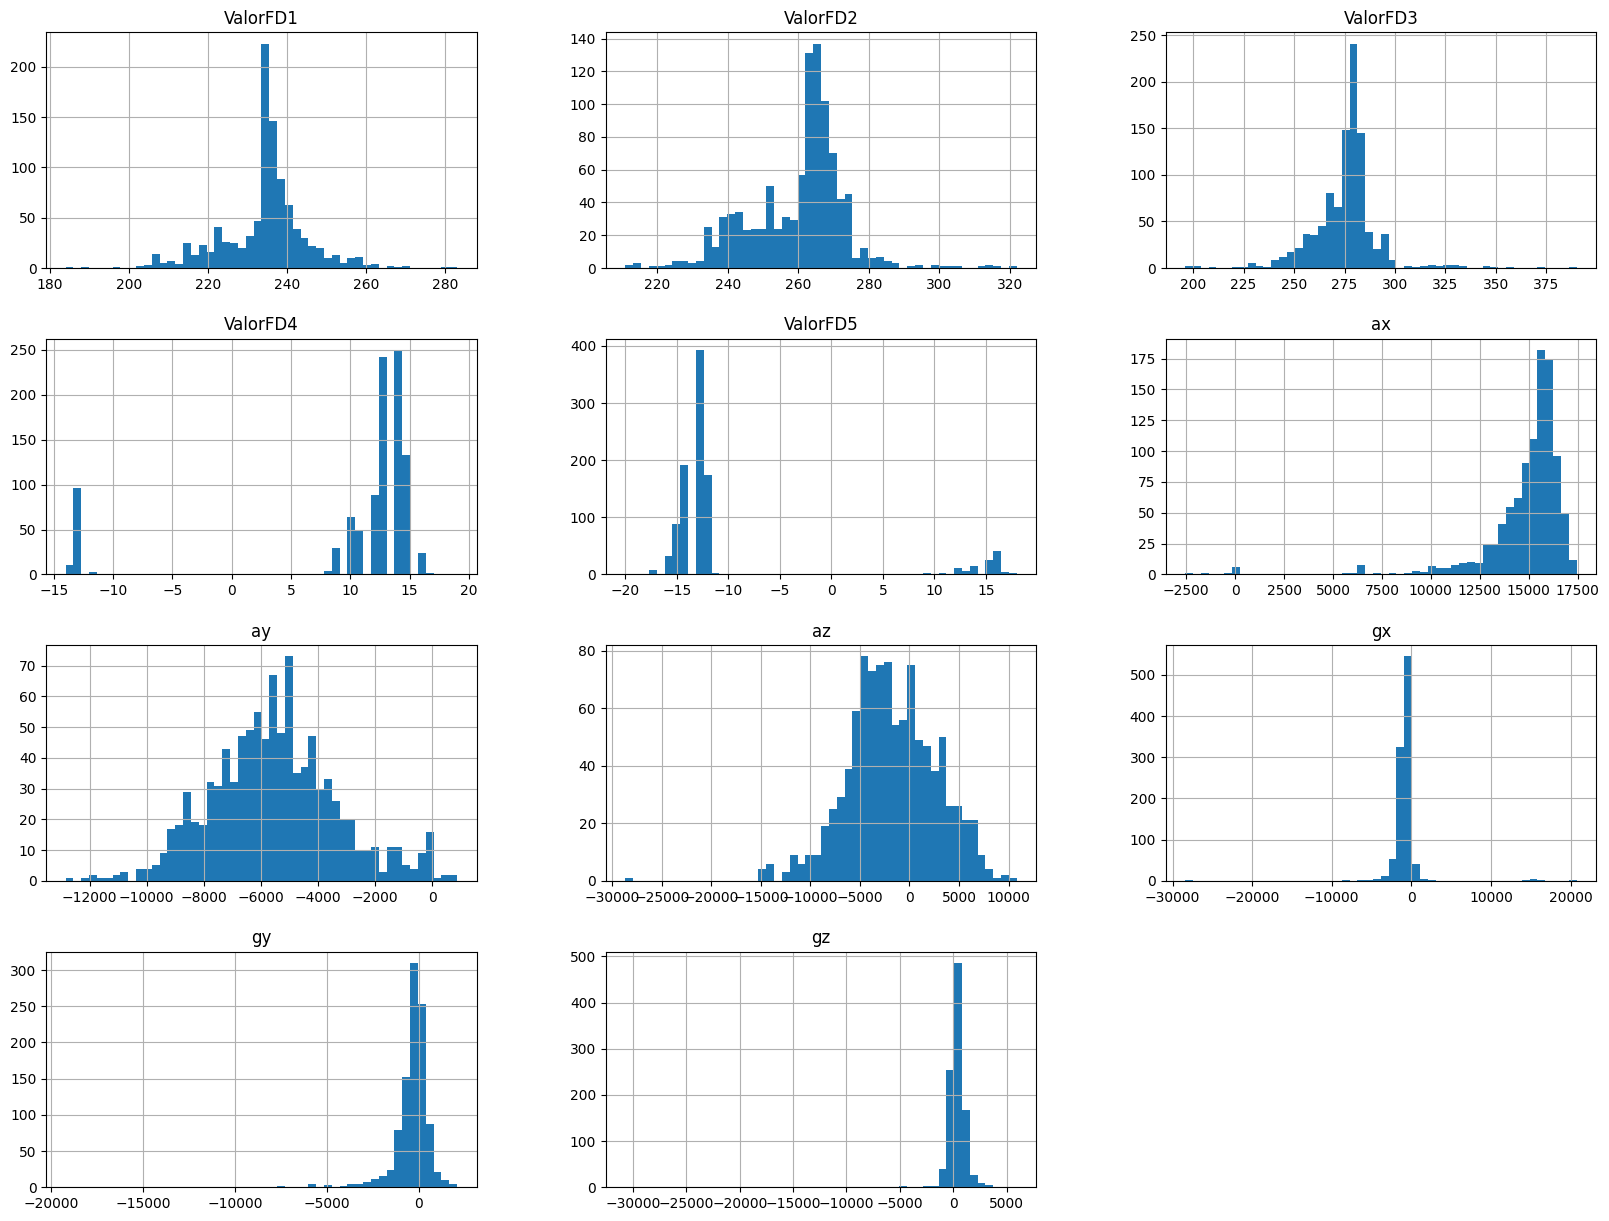

In [115]:
#Genera una matriz con los histogramas
%matplotlib inline
import matplotlib.pyplot as plt

#Muestra los histogramas de los elementos
ms_copy.hist(bins=50,figsize=(20,15))
plt.show()

In [116]:
for k, v in ms_copy.items():
    # Calcular el primer cuartil (Q1)
    q1 = v.quantile(0.25)
    
    # Calcular el tercer cuartil (Q3)
    q3 = v.quantile(0.75)
    
    # Calcular el rango intercuartílico (IQR)
    irq = q3 - q1
    
    # Filtrar los valores atípicos (outliers)
    v_col = v[(v <= q1 - 1.5 * irq) | (v >= q3 + 1.5 * irq)]
    
    # Calcular el porcentaje de valores atípicos respecto al total de filas en el DataFrame
    perc = np.shape(v_col)[0] * 100.0 / np.shape(ms_copy)[0]
    
    # Imprimir el porcentaje de valores atípicos para la columna actual
    print("Column %s outliers = %.2f%%" % (k, perc))

Column ValorFD1 outliers = 10.30%
Column ValorFD2 outliers = 2.90%
Column ValorFD3 outliers = 6.90%
Column ValorFD4 outliers = 11.20%
Column ValorFD5 outliers = 11.80%
Column ax outliers = 6.70%
Column ay outliers = 2.40%
Column az outliers = 1.20%
Column gx outliers = 6.00%
Column gy outliers = 7.60%
Column gz outliers = 4.20%


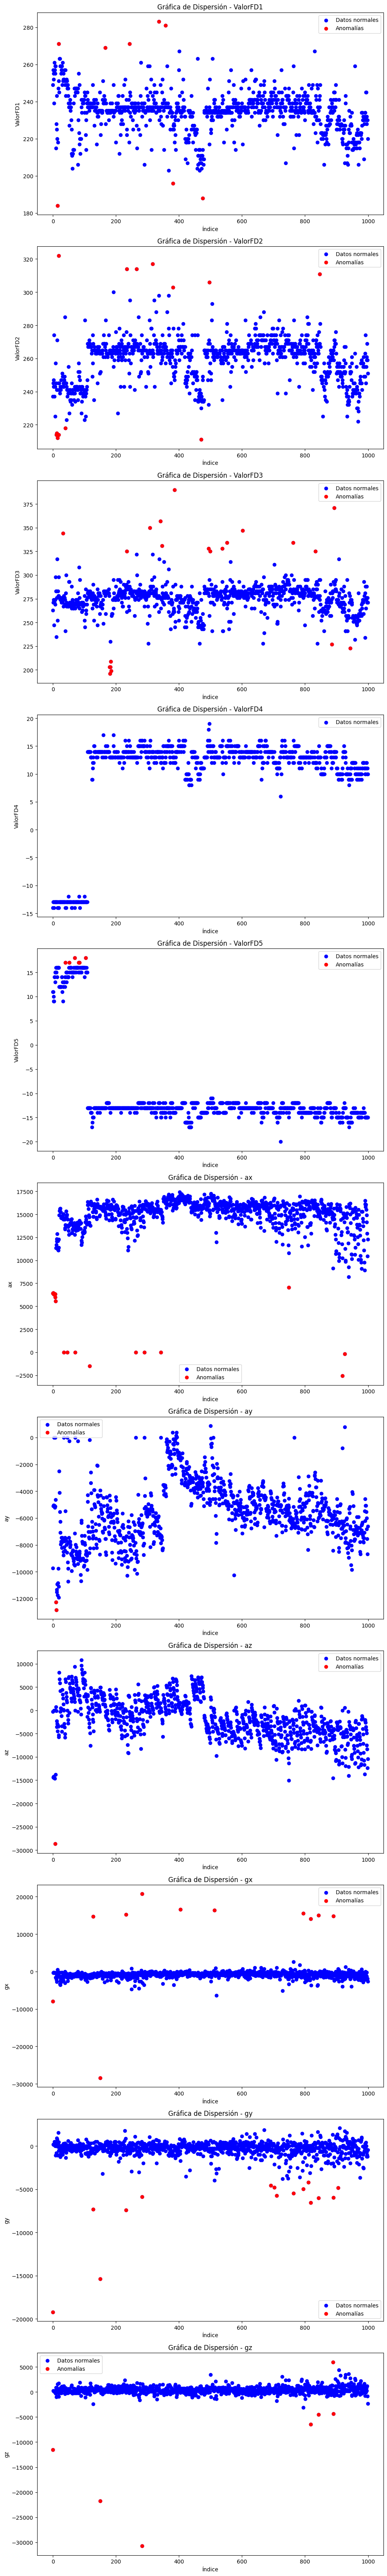

In [117]:
import matplotlib.pyplot as plt

# Crear una figura y un conjunto de ejes
fig, axes = plt.subplots(nrows=len(ms_copy.columns), figsize=(10, 6*len(ms_copy.columns)))

# Iterar a través de cada columna de datos
for i, (column, values) in enumerate(ms_copy.items()):
    # Calcular los límites para definir las anomalías (por ejemplo, ± 3 desviaciones estándar)
    anomaly_lower = values.mean() - 3 * values.std()
    anomaly_upper = values.mean() + 3 * values.std()

    # Crear una gráfica de dispersión de la columna de datos
    axes[i].scatter(range(len(values)), values, color='blue', label='Datos normales')

    # Filtrar y mostrar las anomalías en rojo
    anomalies = values[(values < anomaly_lower) | (values > anomaly_upper)]
    if len(anomalies) > 0:
        axes[i].scatter(anomalies.index, anomalies, color='red', label='Anomalías')

    # Configurar los límites y etiquetas de los ejes
    axes[i].set_ylabel(column)
    axes[i].set_xlabel('Índice')
    axes[i].set_title('Gráfica de Dispersión - {}'.format(column))
    axes[i].legend()

# Ajustar el espaciado entre subtramas
plt.tight_layout()

# Mostrar la gráfica
plt.show()

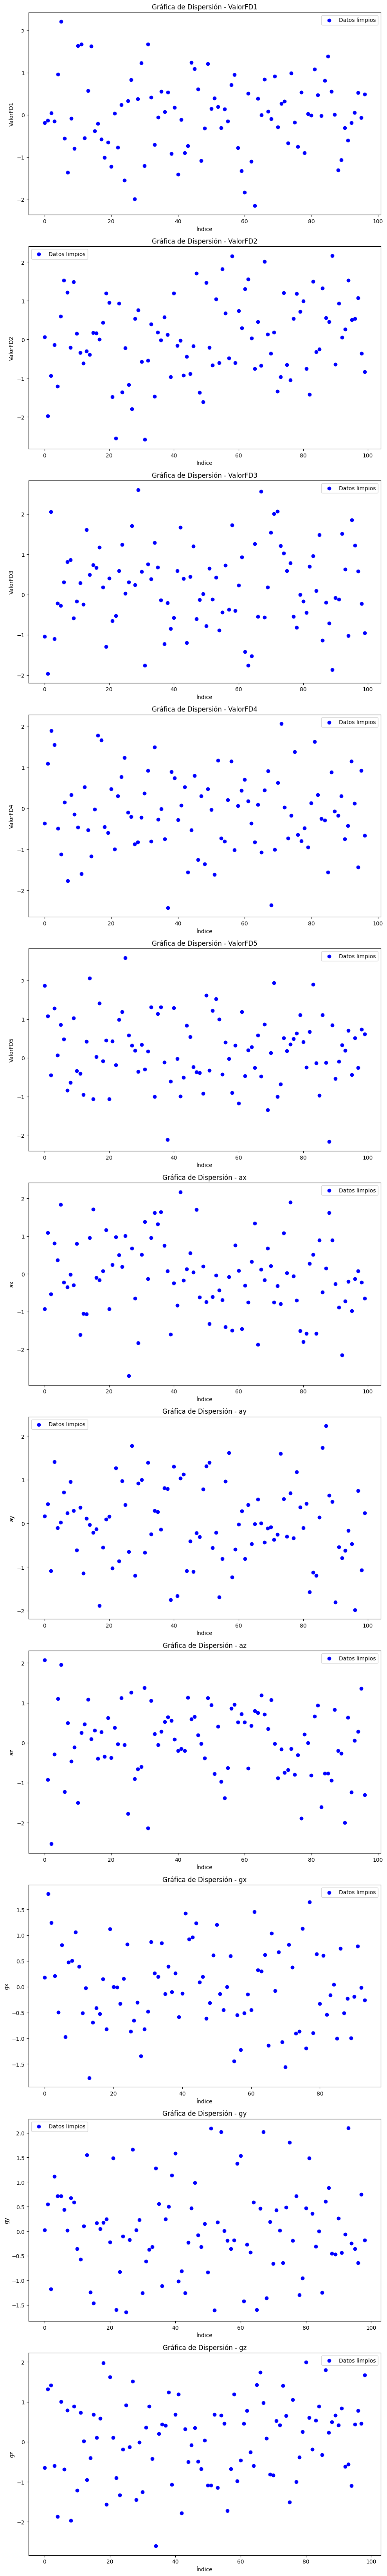

In [155]:
import matplotlib.pyplot as plt

# Crear una figura y un conjunto de ejes
fig, axes = plt.subplots(nrows=len(ms_copy.columns), figsize=(10, 6*len(ms_copy.columns)))

# Iterar a través de cada columna de datos
for i, (column, values) in enumerate(ms_copy.items()):
    # Calcular los límites para definir las anomalías (por ejemplo, ± 3 desviaciones estándar)
    anomaly_lower = values.mean() - 3 * values.std()
    anomaly_upper = values.mean() + 3 * values.std()

    # Filtrar y eliminar las anomalías del DataFrame
    cleaned_values = values[(values >= anomaly_lower) & (values <= anomaly_upper)]

    # Crear una gráfica de dispersión de los datos limpios
    axes[i].scatter(range(len(cleaned_values)), cleaned_values, color='blue', label='Datos limpios')

    # Configurar los límites y etiquetas de los ejes
    axes[i].set_ylabel(column)
    axes[i].set_xlabel('Índice')
    axes[i].set_title('Gráfica de Dispersión - {}'.format(column))
    axes[i].legend()

    # Actualizar el DataFrame ms_copy con los datos limpios
    ms_copy[column] = cleaned_values

# Ajustar el espaciado entre subtramas
plt.tight_layout()

# Mostrar la gráfica
plt.show()


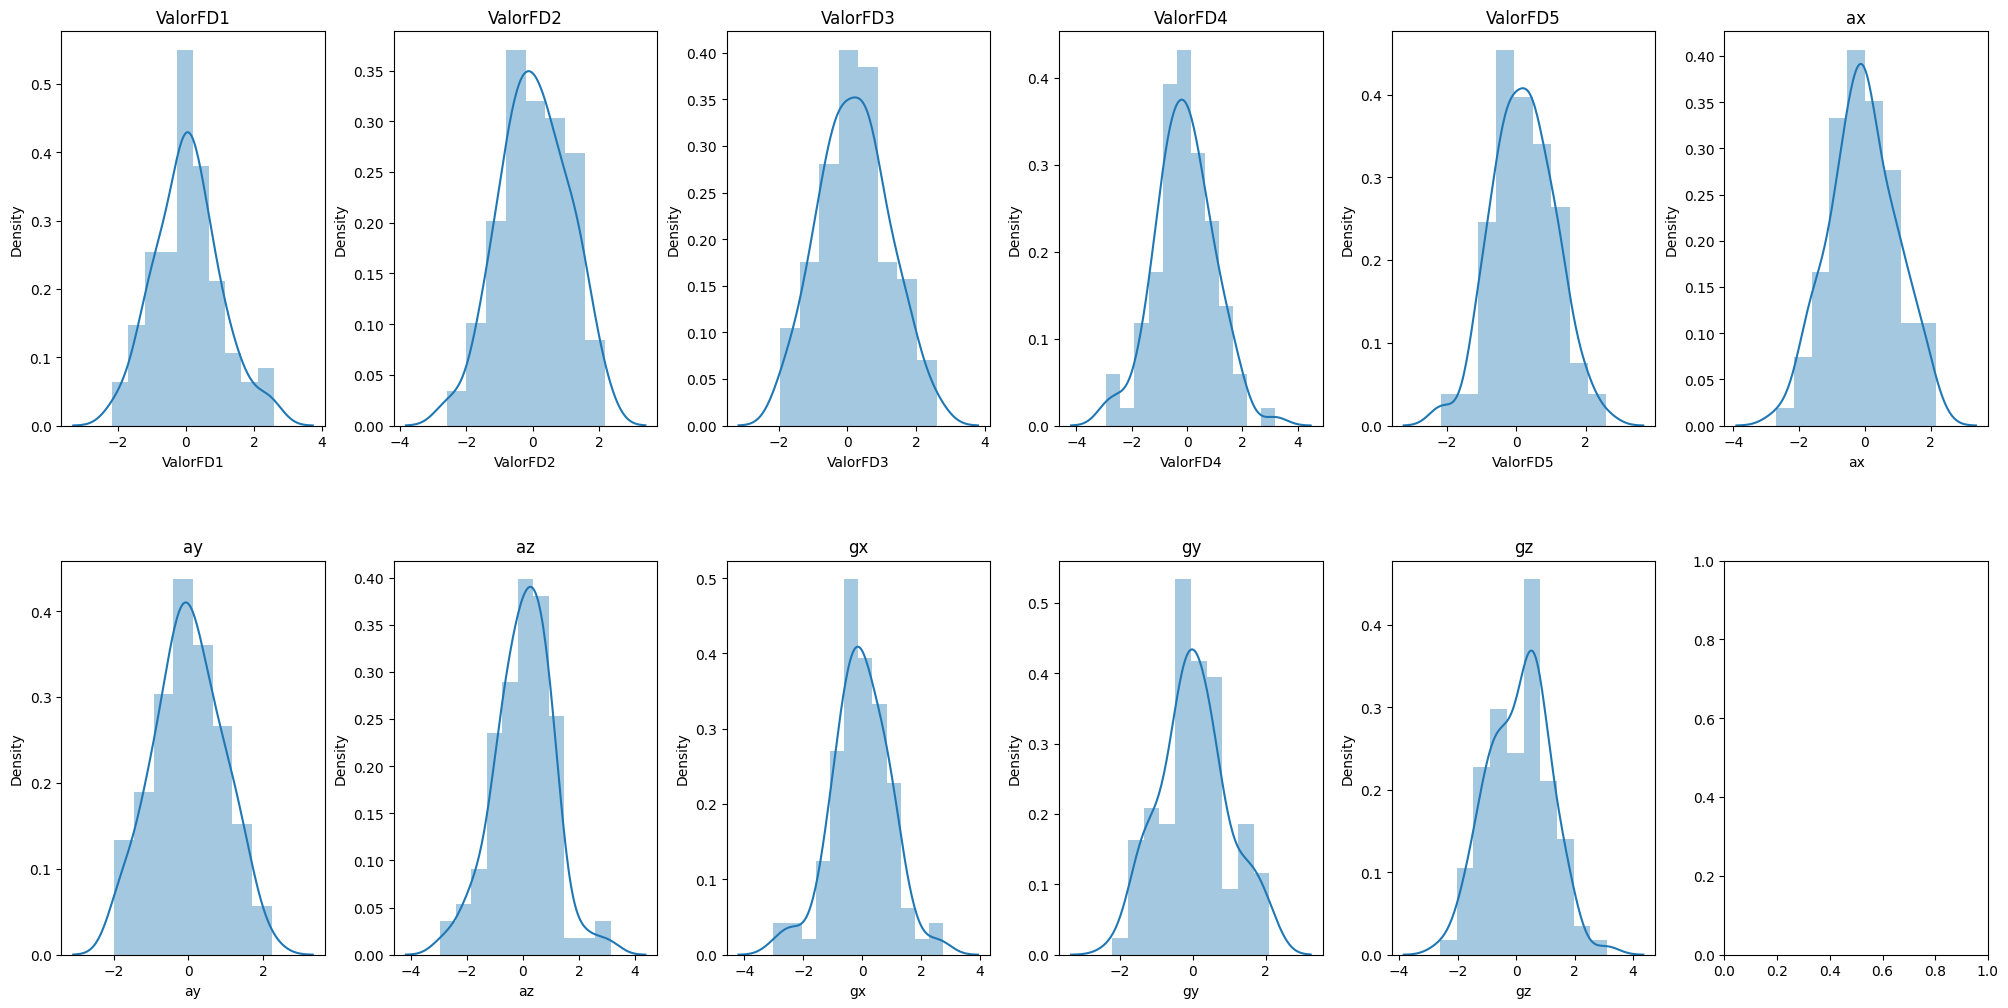

In [124]:
ms_copy = pd.DataFrame({
    "ValorFD1": np.random.randn(100),
    "ValorFD2": np.random.randn(100),
    "ValorFD3": np.random.randn(100),
    "ValorFD4": np.random.randn(100),
    "ValorFD5": np.random.randn(100),
    "ax": np.random.randn(100),
    "ay": np.random.randn(100),
    "az": np.random.randn(100),
    "gx": np.random.randn(100),
    "gy": np.random.randn(100),
    "gz": np.random.randn(100),
})

# Crear una figura con 2 filas y 7 columnas de subplots, con un tamaño de 20x10 pulgadas.
fig, axs = plt.subplots(ncols=6, nrows=2, figsize=(20, 10))

# Inicializar un índice para rastrear la posición del subplot actual
index = 0

# "Aplanar" la matriz de subplots para que sea más fácil iterar sobre ellos
axs = axs.flatten()

# Iterar a través de las columnas en el DataFrame
for k, v in ms_copy.items():
    # Crear un histograma (distribución) para la columna actual en el subplot actual
    sns.distplot(v, ax=axs[index])
    
    # Configurar el título del subplot con el nombre de la columna
    axs[index].set_title(k)
    
    # Incrementar el índice para pasar al siguiente subplot
    index += 1

# Ajustar el diseño de los subplots para evitar superposiciones
plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=5.0)

# Mostrar el gráfico resultante
plt.show()


In [119]:

ms_copy.corr()

,ValorFD1,ValorFD2,ValorFD3,ValorFD4,ValorFD5,ax,ay,az,gx,gy,gz,target
ValorFD1,1.000000,-0.022509,0.055688,0.129729,-0.233616,-0.049325,-0.022762,0.046289,0.021210,-0.002624,0.068857,-0.117382
ValorFD2,-0.022509,1.000000,-0.098237,-0.058553,-0.056632,-0.012458,0.078803,-0.105961,0.164344,-0.033091,0.100361,-0.282151
ValorFD3,0.055688,-0.098237,1.000000,0.111279,0.065042,-0.027621,-0.127394,-0.231618,-0.029046,0.076453,-0.061718,-0.029412
ValorFD4,0.129729,-0.058553,0.111279,1.000000,0.024248,-0.024773,0.053760,0.032270,-0.071840,-0.068686,-0.062512,0.132183
ValorFD5,-0.233616,-0.056632,0.065042,0.024248,1.000000,-0.123732,0.171602,-0.219807,0.013169,-0.018964,-0.064317,0.104161
ax,-0.049325,-0.012458,-0.027621,-0.024773,-0.123732,1.000000,-0.059658,0.058981,0.229907,-0.047058,0.194740,0.017535
ay,-0.022762,0.078803,-0.127394,0.053760,0.171602,-0.059658,1.000000,-0.106698,0.277214,-0.111600,0.019966,-0.001868
az,0.046289,-0.105961,-0.231618,0.032270,-0.219807,0.058981,-0.106698,1.000000,-0.178298,0.044834,-0.021652,-0.021788
gx,0.021210,0.164344,-0.029046,-0.071840,0.013169,0.229907,0.277214,-0.178298,1.000000,-0.191772,0.147101,0.006049
gy,-0.002624,-0.033091,0.076453,-0.068686,-0.018964,-0.047058,-0.111600,0.044834,-0.191772,1.000000,-0.113535,0.042971


In [150]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en características (X) y etiquetas (y)
X = data[:, :-1]  # Todas las columnas excepto la última (características)
y = data[:, -1]   # Última columna (etiquetas)

# Dividir en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Imprimir las formas de los conjuntos resultantes
print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de y_test:", y_test.shape)

Forma de X_train: (80, 20)
Forma de X_test: (20, 20)
Forma de y_train: (80,)
Forma de y_test: (20,)


In [144]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Supongamos que data es tu array de NumPy con 20 características por muestra
# y el objetivo en la última columna

# Separar las características (X) y el objetivo (y)
X = data[:, :-1]  # Todas las columnas excepto la última
y = data[:, -1]   # Última columna, que es el objetivo

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear el modelo de regresión lineal
regression_model = LinearRegression()

# Entrenar el modelo con los datos de entrenamiento
regression_model.fit(X_train, y_train)

# Hacer predicciones en los datos de prueba
y_pred = regression_model.predict(X_test)

# Calcular el error cuadrático medio en los datos de prueba
mse = mean_squared_error(y_test, y_pred)
print("Error cuadrático medio:", mse)


Error cuadrático medio: 0.09824268506395725
